<h1>PART A</h1>

# Homework: Comparing BERT Fine-Tuning Scenarios

## Objective

This homework aims to provide a practical understanding of different approaches to fine-tuning BERT for a text classification task. You will explore three scenarios:
1.  **Full Fine-Tuning**: Fine-tuning all layers of a pre-trained BERT model.
2.  **LoRA Fine-Tuning**: Using Low-Rank Adaptation (LoRA) for parameter-efficient fine-tuning.
3.  **Few-Shot Learning**: Adapting BERT for a scenario with limited training data, typically by freezing the base model and training a small classification head.

You will compare the performance of these methods on a dataset of book descriptions and their genres (titles).

## Setup

Before you begin, ensure you have the necessary libraries installed and the dataset ready.

### 1. Install Libraries

Run the first cell to install `torchao` and other dependencies. You might also need `transformers` and `peft`.

### 2. Load and Preprocess Data

**TODO**: Ensure your `preprocessed.json` dataset is loaded and ready for use.

```python
# TODO: Add code to load your dataset if it's not already handled in the notebook.
# Example: Load your JSON data from a specific path
# with open("/path/to/your/dataset.json", "r", encoding="utf-8") as f:
#     data = json.load(f)
```

## Notebook Structure

This notebook is divided into several sections:

### 1. Dataset Classes (`TitleLabelEncoder`, `GoodreadsDataset`)

-   `TitleLabelEncoder`: A utility class to convert categorical labels (book titles/genres) into numerical IDs and vice-versa. This is essential for training classification models.
-   `GoodreadsDataset`: A PyTorch `Dataset` class that prepares your text and labels for input into a BERT model. It handles tokenization using a pre-trained BERT tokenizer.

### 2. Base Model (`BaseClassifier`)

An abstract base class for our classification models. All concrete model implementations will inherit from this, ensuring a consistent interface.

### 3. Full Fine-Tuning (`FullFineTuneBERT`)

This section defines a model that takes a pre-trained `bert-base-uncased` model and adds a linear classification head on top. During training, all parameters of the BERT model are updated along with the classification head.

### 4. LoRA Fine-Tuning (`LoRABERTClassifier`)

This class implements LoRA (Low-Rank Adaptation) for fine-tuning. Instead of updating all BERT parameters, LoRA injects small, trainable rank-decomposition matrices into existing layers. This significantly reduces the number of trainable parameters while often achieving comparable performance.

### 5. Few-Shot Learning (`FewShotCLSClassifier`)

This scenario is designed for situations with very limited training data. Here, the pre-trained BERT model's parameters are frozen, and only a small, custom classification head (a simple neural network) is trained on top of BERT's `[CLS]` token embedding.

### 6. Trainer (`Trainer`)

This class encapsulates the training and evaluation logic. It includes methods for:

-   `train_epoch`: Performs one epoch of training, including forward pass, loss calculation, backward pass, and optimizer step.
-   `evaluate_epoch`: Evaluates the model on a validation set, calculating the loss without updating weights.
-   `evaluate_accuracy`: Calculates the classification accuracy on a given DataLoader.

### 7. Configuration & Data Preparation

This section sets up global configurations (like random seed, number of epochs, learning rates for each scenario) and prepares the dataset.

-   **SEED**: For reproducibility.
-   **SCENARIOS_TO_RUN**: A list of scenarios to execute.
-   **EPOCHS & LEARNING_RATES**: Hyperparameters for training.
-   **Data Preparation**: This involves extracting texts and labels, encoding labels using `TitleLabelEncoder`, tokenizing with `BertTokenizer`, creating a `GoodreadsDataset`, and splitting it into training and validation sets using `random_split`.
-   **DataLoader**: Creates `DataLoader` objects for efficient batching during training and evaluation.

### 8. Scenario Runner Function (`run_scenario`)

A helper function to orchestrate the training and evaluation for a single scenario. It selects the appropriate model, sets up the optimizer and loss function, and runs the training loop.

### 9. Run All Scenarios and Compare

This is the main execution block where each defined scenario is run using the `run_scenario` function. It collects the final validation accuracy for each scenario and prints a comparison.

### 10. Small Data Scenarios

This section duplicates the configuration and data preparation, but specifically for a smaller subset of the original data. This is crucial for observing how the different fine-tuning approaches behave under data scarcity.

Good luck!

In [1]:
!pip install torchao==0.16.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 49.7 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [2]:
import json
import torch
import torch.nn as nn
from abc import ABC, abstractmethod
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import BertModel, BertTokenizer
from peft import LoraConfig, get_peft_model
from tqdm import tqdm
import pandas as pd
import random
import numpy as np
from torch.optim import AdamW

In [3]:
import gdown

url = "https://drive.google.com/file/d/1KGPZ7lKkxkPR4azBRLxEoG7ngo8EXrDC/view?usp=drive_link"
output = "books_with_description_emb.csv"

gdown.download(url, output, quiet=False, fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=1KGPZ7lKkxkPR4azBRLxEoG7ngo8EXrDC
To: /content/books_with_description_emb.csv
100%|██████████| 72.8M/72.8M [00:00<00:00, 199MB/s]


'books_with_description_emb.csv'

In [4]:
CSV_PATH = "books_with_description_emb.csv"

try:
    data = pd.read_csv(CSV_PATH)
except pd.errors.ParserError:
    # Use the slower Python parser if the CSV contains difficult quoted fields.
    data = pd.read_csv(CSV_PATH, engine='python')

display(data.head())

,Unnamed: 0,bookId,title,author,series,description,genres,awards,characters,places,...,num_pages,num_ratings,num_reviews,avg_rating,rated_1,rated_2,rated_3,rated_4,rated_5,description_emb
0,4249,4255,Harry Potter and the Philosopher's Stone,J.K. Rowling,Harry Potter #1,When a letter arrives for unhappy but ordinary...,"Art,Biography,Business,Children's,Christian,Cl...",Mythopoeic Fantasy Award for Children's Litera...,"Draco Malfoy,Ron Weasley,Petunia Dursley,Verno...","London, England,Hogwarts School of Witchcraft ...",...,223.0,7437005,117859,4.48,126396,147247,627970,1694668,4840724,"[-0.0039046169258654118, -0.023151082918047905..."
1,2,3,Harry Potter and the Sorcerer's Stone,"J.K. Rowling,Mary GrandPré",Harry Potter #1,Harry Potter's life is miserable. His parents ...,"Art,Biography,Business,Children's,Christian,Cl...",Mythopoeic Fantasy Award for Children's Litera...,"Draco Malfoy,Ron Weasley,Petunia Dursley,Verno...","London, England,Hogwarts School of Witchcraft ...",...,309.0,7434783,117823,4.48,126344,147184,627803,1694206,4839246,"[0.006142752710729837, -0.03195742145180702, -..."
2,12110,12024,Twilight,Stephenie Meyer,The Twilight Saga #1,"About three things I was absolutely positive.,...","Art,Biography,Business,Children's,Christian,Cl...","Georgia Peach Book Award 2007,Buxtehuder Bulle...","Edward Cullen,Jacob Black,Laurent,Renee,Bella ...","Forks, Washington,Phoenix, Arizona,Washington ...",...,544.0,5173079,106718,3.61,562807,560978,1052619,1164865,1831810,"[0.055690325796604156, -0.03585127741098404, -..."
3,2656,2661,To Kill a Mockingbird,Harper Lee,To Kill a Mockingbird,Lawyer Atticus Finch defends the real mockingb...,"Art,Biography,Business,Children's,Christian,Cl...","Pulitzer Prize for Fiction 1961,Audie Award fo...","Scout Finch,Atticus Finch,Jem Finch,Arthur Rad...","Maycomb, Alabama,Alabama",...,323.0,4712812,94358,4.28,85019,156544,598802,1395089,2477358,"[0.056648898869752884, -0.02620820701122284, 0..."
4,2655,2660,To Kill a Mockingbird,Harper Lee,To Kill a Mockingbird,Harper Lee's classic novel of a lawyer in the ...,"Art,Biography,Business,Children's,Christian,Cl...","Pulitzer Prize for Fiction 1961,Audie Award fo...","Scout Finch,Atticus Finch,Jem Finch,Arthur Rad...","Maycomb, Alabama,Alabama",...,284.0,4712812,94358,4.28,85019,156544,598802,1395089,2477358,"[0.020673654973506927, -0.026255520060658455, ..."


In [ ]:
# !unzip /content/MIR-Project-SP2026-main.zip
#import json
#with open("/kaggle/input/datasets/fatemehaskari/book-data/MIR-Project-SP2026-main/answer/preprocessed.json", "r", encoding="utf-8") as f:
#    data = json.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/fatemehaskari/book-data/MIR-Project-SP2026-main/answer/preprocessed.json'

# 1. Dataset Class

In [5]:
class TitleLabelEncoder:

    def __init__(self):

        self.title_to_id = {}
        self.id_to_title = {}

    def fit(self, titles):

        unique_titles = sorted(set(titles))

        self.title_to_id = {
            title: idx
            for idx, title in enumerate(unique_titles)
        }

        self.id_to_title = {
            idx: title
            for title, idx in self.title_to_id.items()
        }

    def encode(self, title):
        return self.title_to_id[title]

    def decode(self, idx):
        return self.id_to_title[idx]

    def transform(self, titles):
        return [self.encode(title) for title in titles]

    def inverse_transform(self, indices):
        return [self.decode(idx) for idx in indices]

    @property
    def num_classes(self):

        return len(self.title_to_id)


In [6]:
class GoodreadsDataset(Dataset):

    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_length=256
    ):

        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])

        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long),
        }


# 2. Base Model

In [7]:
from abc import ABC, abstractmethod
import torch.nn as nn

class BaseClassifier(nn.Module, ABC):

    @abstractmethod
    def forward(self, input_ids, attention_mask):
        pass

# 3. First Scenario: Full Fine-Tuning

In [8]:
class FullFineTuneBERT(BaseClassifier):

    def __init__(self, num_classes):

        super().__init__()

        self.bert = BertModel.from_pretrained(
            "bert-base-uncased"
        )

        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_output)

        return logits


# 4. Second Scenarion: LoRA Fine-Tuning

In [9]:
class LoRABERTClassifier(BaseClassifier):

    def __init__(self, num_classes):

        super().__init__()

        model = BertModel.from_pretrained(
            "bert-base-uncased"
        )

        lora_config = LoraConfig(
            r=8,
            lora_alpha=16,
            target_modules=["query", "value"],
            lora_dropout=0.1,
            bias="none"
        )

        self.bert = get_peft_model(model, lora_config)

        self.classifier = nn.Linear(model.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_output)

        return logits


# 4. Third Scenarion: Few-Shot Learning

In [10]:
class FewShotCLSClassifier(BaseClassifier):

    def __init__(self, num_classes):

        super().__init__()

        self.bert = BertModel.from_pretrained(
            "bert-base-uncased"
        )

        # Freeze BERT
        for param in self.bert.parameters():
            param.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, num_classes),
        )

    def forward(self, input_ids, attention_mask):

        with torch.no_grad():

            outputs = self.bert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_output)

        return logits


# 5. Trainer

In [12]:
class Trainer:

    def __init__(
        self,
        model,
        optimizer,
        criterion,
        device
    ):

        self.model = model.to(device)
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device

    def train_epoch(self, dataloader):

        self.model.train()

        total_loss = 0

        for batch in tqdm(dataloader):

            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            labels = batch["label"].to(self.device)

            self.optimizer.zero_grad()

            logits = self.model(input_ids=input_ids, attention_mask=attention_mask)

            loss = self.criterion(logits, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

        return total_loss / len(dataloader)

    def evaluate_epoch(self, dataloader):

        self.model.eval()

        total_loss = 0

        with torch.no_grad():

            for batch in tqdm(dataloader):

                input_ids = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                labels = batch["label"].to(self.device)

                logits = self.model(input_ids=input_ids, attention_mask=attention_mask)

                loss = self.criterion(logits, labels)

                total_loss += loss.item()

        return total_loss / len(dataloader)

    def evaluate_accuracy(self, dataloader):

        self.model.eval()

        correct_predictions = 0
        total_predictions = 0

        with torch.no_grad():
            for batch in tqdm(dataloader):
                input_ids = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                labels = batch["label"].to(self.device)

                logits = self.model(input_ids=input_ids, attention_mask=attention_mask)

                predictions = torch.argmax(logits, dim=1)
                correct_predictions += (predictions == labels).sum().item()
                total_predictions += labels.size(0)

        return correct_predictions / total_predictions


# 6. Configuration & Data

In [15]:
# =========================================
# CONFIGURATION
# =========================================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

SCENARIOS_TO_RUN = ["full", "lora", "fewshot"]
EPOCHS = 10
LEARNING_RATES = {
    "full": 2e-5,
    "lora": 1e-4,
    "fewshot": 1e-3,
}

# =========================================
# DATA PREPARATION
# =========================================
title_counts = data['title'].value_counts()
top_10_frequent_titles = title_counts.head(10).index.tolist()
filtered_data = data[data['title'].isin(top_10_frequent_titles)].reset_index(drop=True)

texts = filtered_data['description'].astype(str).tolist()
titles = filtered_data['title'].tolist()

label_encoder = TitleLabelEncoder()
label_encoder.fit(titles)
encoded_labels = label_encoder.transform(titles)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

dataset = GoodreadsDataset(
    texts=texts,
    labels=encoded_labels,
    tokenizer=tokenizer
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

NUM_CLASSES = label_encoder.num_classes
print("Number of classes:", NUM_CLASSES)
print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Number of classes: 10
Training samples: 112, Validation samples: 28


In [16]:
def run_scenario(scenario_name, num_classes, train_loader, val_loader, learning_rate, epochs, device, save_weights=False):
    print(f"\n--- Running Scenario: {scenario_name} ---")

    if scenario_name.startswith("full"):
        model = FullFineTuneBERT(num_classes)
    elif scenario_name.startswith("lora"):
        model = LoRABERTClassifier(num_classes)
    elif scenario_name.startswith("fewshot"):
        model = FewShotCLSClassifier(num_classes)
    else:
        raise ValueError(f"Unknown scenario: {scenario_name}")

    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
    )
    criterion = nn.CrossEntropyLoss()
    trainer = Trainer(model, optimizer, criterion, device=device)

    for epoch in range(epochs):
        train_loss = trainer.train_epoch(train_loader)
        val_loss = trainer.evaluate_epoch(val_loader)
        print(f"Epoch {epoch + 1}/{epochs}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

    if save_weights:
        save_path = f"{scenario_name}_bert_weights.pth"
        torch.save(model.state_dict(), save_path)
        print(f"Model weights for '{scenario_name}' saved to {save_path}")

    final_val_accuracy = trainer.evaluate_accuracy(val_loader)
    print(f"Final Validation Accuracy for {scenario_name}: {final_val_accuracy:.4f}")
    return final_val_accuracy


In [18]:
# =========================================
# RUN ALL SCENARIOS AND COMPARE
# =========================================

results = {}
device = "cuda" if torch.cuda.is_available() else "cpu"

for scenario in SCENARIOS_TO_RUN:
    acc = run_scenario(
        scenario,
        NUM_CLASSES,
        train_loader,
        val_loader,
        LEARNING_RATES[scenario],
        EPOCHS,
        device,
        save_weights=True
    )
    results[scenario] = acc

print("\n--- Scenario Comparison ---")
for scenario, accuracy in results.items():
    print(f"{scenario}: {accuracy:.4f}")

best_scenario = max(results, key=results.get)
print(f"\nBest performing scenario: {best_scenario} with accuracy {results[best_scenario]:.4f}")


--- Running Scenario: full ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 2/2 [00:00<00:00,  3.18it/s]


Epoch 1/10: Train Loss = 2.3097, Val Loss = 2.0772


100%|██████████| 2/2 [00:00<00:00,  4.31it/s]


...

Epoch 9/10: Train Loss = 0.7578, Val Loss = 0.8738


100%|██████████| 2/2 [00:00<00:00,  4.63it/s]


Epoch 10/10: Train Loss = 0.6821, Val Loss = 0.8487
Model weights for 'fewshot' saved to fewshot_bert_weights.pth


100%|██████████| 2/2 [00:00<00:00,  3.93it/s]

Final Validation Accuracy for fewshot: 0.8214

--- Scenario Comparison ---
full: 0.9643
lora: 0.6071
fewshot: 0.8214

Best performing scenario: full with accuracy 0.9643


In [19]:
# =========================================
# CONFIGURATION for small data scenarios
# =========================================

SCENARIOS_TO_RUN_SMALL = ["full", "lora", "fewshot"]
EPOCHS = 10
LEARNING_RATES = {
    "full": 2e-5,
    "lora": 1e-4,
    "fewshot": 1e-3,
}

# =========================================
# Data Preparation for small data scenarios
# =========================================

small_data = len(dataset) // 3
remaining_dataset_length = len(dataset) - small_data
small_dataset_for_split, _ = random_split(
    dataset,
    [small_data, remaining_dataset_length],
    generator=torch.Generator().manual_seed(SEED)
)

train_size_small = int(0.8 * len(small_dataset_for_split))
val_size_small = len(small_dataset_for_split) - train_size_small
train_dataset_small, val_dataset_small = random_split(
    small_dataset_for_split,
    [train_size_small, val_size_small],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"\n--- Data Split for small data scenarios ---")
print(f"Small Data Training samples: {len(train_dataset_small)}, Validation samples: {len(val_dataset_small)}")

train_loader_small = DataLoader(
    train_dataset_small,
    batch_size=16,
    shuffle=True
)
val_loader_small = DataLoader(
    val_dataset_small,
    batch_size=16,
    shuffle=False
)


--- Data Split for small data scenarios ---
Small Data Training samples: 36, Validation samples: 10


In [21]:
# =========================================
# Run small data Scenarios
# =========================================

results_small_data = {}

for scenario in SCENARIOS_TO_RUN_SMALL:
    acc = run_scenario(
        scenario,
        NUM_CLASSES,
        train_loader_small,
        val_loader_small,
        LEARNING_RATES[scenario],
        EPOCHS,
        device
    )
    results_small_data[scenario] = acc

print("\n--- Scenario Comparison ---")
for scenario, accuracy in results_small_data.items():
    print(f"{scenario}: {accuracy:.4f}")

best_scenario_small = max(results_small_data, key=results_small_data.get)
print(f"\nBest performing scenario: {best_scenario_small} with accuracy {results_small_data[best_scenario_small]:.4f}")


--- Running Scenario: full ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 1/1 [00:00<00:00,  6.80it/s]


Epoch 1/10: Train Loss = 2.3700, Val Loss = 2.2690


100%|██████████| 1/1 [00:00<00:00,  7.29it/s]


...

Epoch 9/10: Train Loss = 1.3536, Val Loss = 1.8135


100%|██████████| 1/1 [00:00<00:00,  6.76it/s]


Epoch 10/10: Train Loss = 1.2748, Val Loss = 1.7842


100%|██████████| 1/1 [00:00<00:00,  6.57it/s]

Final Validation Accuracy for fewshot: 0.2000

--- Scenario Comparison ---
full: 0.8000
lora: 0.1000
fewshot: 0.2000

Best performing scenario: full with accuracy 0.8000


<h1>PART B</h1>

<div style="font-size: 20px; line-height: 1.7;">

In this part, we analyze how BERT representations change across layers before and after fine-tuning.

We compare two models:

1. **Pretrained BERT**: the original BERT model without task-specific training.
2. **Full Fine-Tuned BERT**: the BERT model after being trained on the book title classification task.

For each model, we extract the hidden representation of the `[CLS]` token from every BERT layer. The `[CLS]` vector is used because it represents the whole input description and is also used by the classifier for prediction.

Then, we apply **PCA** to project these high-dimensional vectors into 2D space and visualize them. Each point represents one book description, and colors correspond to the true book title class.

Finally, we compute the **Silhouette Score** for each layer to measure how well the class representations are separated. A higher score means that samples from the same class are closer together and samples from different classes are farther apart.

The goal is to see whether fine-tuning makes the upper BERT layers more task-specific and better separated for the classification task.

</div>

In [22]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

<h2>Main Configuration</h2>

In [26]:
# =========================================
# Main visualization configuration
# =========================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Path to the saved full fine-tuned BERT weights.
# This should match the file saved during your training stage.
FULL_FINETUNED_CKPT = FULL_FINETUNED_CKPT = "full_bert_weights.pth"


# Directory where all plots and CSV files will be saved.
OUTPUT_DIR = "layerwise_bert_visualizations"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Use only part of the validation set for faster visualization.
# Set this to None if you want to use the entire validation set.
MAX_BATCHES = 20

# Pooling method:
# "cls"  = use the [CLS] token representation.
# "mean" = average all valid token representations.
POOLING = "cls"

# Selected layers for detailed plots.
# Layer 0 is the embedding output.
# Layers 1 to 12 are Transformer encoder layers.
SELECTED_LAYERS = [0, 1, 4, 8, 12]

print("Device:", DEVICE)
print("Output directory:", OUTPUT_DIR)
print("Pooling method:", POOLING)

Device: cuda
Output directory: layerwise_bert_visualizations
Pooling method: cls


<h2>Build Pretrained and Fine-Tuned Models</h2>

In [27]:
def build_pretrained_model(num_classes, device):
    model = FullFineTuneBERT(num_classes)
    model.to(device)
    model.eval()
    return model


def build_finetuned_model(num_classes, checkpoint_path, device):
    model = FullFineTuneBERT(num_classes)
    checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict, strict=True)
    model.to(device)
    model.eval()
    return model


pretrained_model = build_pretrained_model(NUM_CLASSES, DEVICE)
finetuned_model = build_finetuned_model(NUM_CLASSES, FULL_FINETUNED_CKPT, DEVICE)

print("Pretrained BERT model is ready.")
print("Full fine-tuned BERT model is ready.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pretrained BERT model is ready.
Full fine-tuned BERT model is ready.


<h2>Pooling Functions</h2>

In [28]:
# =========================================
# Pooling functions
# =========================================

def mean_pooling(hidden_state, attention_mask):
    """
    Compute mean pooling over valid tokens.

    Args:
        hidden_state:
            Tensor of shape [batch_size, seq_len, hidden_dim]

        attention_mask:
            Tensor of shape [batch_size, seq_len]
            1 means valid token, 0 means padding token.

    Returns:
        Tensor of shape [batch_size, hidden_dim]
    """
    mask = attention_mask.unsqueeze(-1).expand(hidden_state.size()).float()
    masked_hidden_state = hidden_state * mask
    summed_hidden_state = torch.sum(masked_hidden_state, dim=1)
    valid_token_count = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed_hidden_state / valid_token_count



def pool_hidden_state(hidden_state, attention_mask, pooling="cls"):
    """
    Convert token-level hidden states into one vector per input sample.

    Args:
        hidden_state:
            Tensor of shape [batch_size, seq_len, hidden_dim]

        attention_mask:
            Tensor of shape [batch_size, seq_len]

        pooling:
            "cls" or "mean"

    Returns:
        Tensor of shape [batch_size, hidden_dim]
    """
    if pooling == "cls":
        return hidden_state[:, 0, :]
    if pooling == "mean":
        return mean_pooling(hidden_state, attention_mask)
    raise ValueError("pooling must be either 'cls' or 'mean'")


<h2>Extract Layer-Wise Representations</h2>

In [31]:
# =========================================
# Extract layer-wise representations
# =========================================

def extract_layer_representations(
    model,
    dataloader,
    device,
    pooling="cls",
    max_batches=None
):
    """
    Extract one representation vector per sample from every BERT layer.

    Args:
        model:
            A model that contains model.bert.

        dataloader:
            Validation or test DataLoader.

        device:
            "cuda" or "cpu".

        pooling:
            "cls" or "mean".

        max_batches:
            Maximum number of batches to process.
            Use None to process the full dataloader.

    Returns:
        layer_vectors:
            Dictionary:
                key   = layer index
                value = numpy array of shape [num_samples, hidden_dim]

        all_labels:
            Numpy array of shape [num_samples]
    """
    model.eval()

    layer_vectors = None
    all_labels = []

    with torch.no_grad():

        for batch_idx, batch in enumerate(tqdm(dataloader)):

            if max_batches is not None and batch_idx >= max_batches:
                break

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model.bert(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True,
            )

            hidden_states = outputs.hidden_states

            if layer_vectors is None:
                layer_vectors = {
                    layer_idx: []
                    for layer_idx in range(len(hidden_states))
                }

            for layer_idx, hidden_state in enumerate(hidden_states):

                pooled_vectors = pool_hidden_state(hidden_state, attention_mask, pooling=pooling)

                layer_vectors[layer_idx].append(
                    pooled_vectors.detach().cpu().numpy()
                )

            all_labels.append(labels.detach().cpu().numpy())

    for layer_idx in layer_vectors:
        layer_vectors[layer_idx] = np.concatenate(layer_vectors[layer_idx], axis=0)

    all_labels = np.concatenate(all_labels, axis=0)

    return layer_vectors, all_labels

<h2>Extract Representations for Both Models</h2>

In [32]:
# =========================================
# Extract representations from pretrained and fine-tuned models
# =========================================

pretrained_layer_vectors, y_labels = extract_layer_representations(
    model=pretrained_model,
    dataloader=val_loader,
    device=DEVICE,
    pooling=POOLING,
    max_batches=MAX_BATCHES
)

finetuned_layer_vectors, y_labels_finetuned = extract_layer_representations(
    model=finetuned_model,
    dataloader=val_loader,
    device=DEVICE,
    pooling=POOLING,
    max_batches=MAX_BATCHES
)

assert np.array_equal(y_labels, y_labels_finetuned)

print("Representation extraction finished.")
print("Number of samples:", len(y_labels))
print("Number of layers:", len(pretrained_layer_vectors))
print("Shape of layer 12 vectors:", pretrained_layer_vectors[12].shape)

100%|██████████| 2/2 [00:00<00:00,  4.34it/s]

Representation extraction finished.
Number of samples: 28
Number of layers: 13
Shape of layer 12 vectors: (28, 768)


<h2>Helper Function for Short Class Names</h2>

In [33]:
# =========================================
# Label helper functions
# =========================================

def shorten_text(text, max_length=35):
    """
    Shorten long text labels for plot legends.
    """
    text = str(text)

    if len(text) <= max_length:
        return text

    return text[:max_length] + "..."


def get_class_name(label_id, label_encoder, max_length=35):
    """
    Convert numeric class ID to a readable class name.
    """
    class_name = label_encoder.decode(label_id)
    return shorten_text(class_name, max_length=max_length)



class_names = [
    get_class_name(i, label_encoder)
    for i in range(NUM_CLASSES)
]

for idx, name in enumerate(class_names):
    print(idx, "->", name)

0 -> A Tale of Two Cities
1 -> Anna Karenina
2 -> One Hundred Years of Solitude
3 -> Pride and Prejudice
4 -> Siddhartha
5 -> The Brothers Karamazov
6 -> The House of Mirth
7 -> The Lord of the Rings
8 -> The Picture of Dorian Gray
9 -> The Silmarillion


<h2>PCA Visualization for One Model and One Layer</h2>

In [34]:
# =========================================
# PCA visualization for one model and one layer
# =========================================

def visualize_single_layer_pca(
    vectors,
    labels,
    label_encoder,
    title,
    output_file
):
    """
    Visualize vectors from a single BERT layer using 2D PCA.

    Args:
        vectors:
            Numpy array of shape [num_samples, hidden_dim]

        labels:
            Numpy array of shape [num_samples]

        label_encoder:
            Fitted label encoder used to decode class IDs.

        title:
            Plot title.

        output_file:
            Path where the plot will be saved.
    """
    pca = PCA(n_components=2, random_state=42)
    reduced_vectors = pca.fit_transform(vectors)


    plt.figure(figsize=(10, 8))

    unique_labels = sorted(np.unique(labels))

    for label_id in unique_labels:

        indices = labels == label_id

        plt.scatter(
            reduced_vectors[indices, 0],
            reduced_vectors[indices, 1],
            s=35,
            alpha=0.75,
            label=get_class_name(label_id, label_encoder)
        )

    plt.title(title)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, loc="best")
    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    plt.close()

    print("Saved:", output_file)

<h2>Visualize Selected Layers Separately</h2>

In [35]:
# =========================================
# Visualize selected layers separately
# =========================================

for layer_idx in SELECTED_LAYERS:

    pretrained_output_file = os.path.join(
        OUTPUT_DIR,
        f"pretrained_layer_{layer_idx}_{POOLING}_pca.png"
    )

    finetuned_output_file = os.path.join(
        OUTPUT_DIR,
        f"finetuned_layer_{layer_idx}_{POOLING}_pca.png"
    )

    visualize_single_layer_pca(
        vectors=pretrained_layer_vectors[layer_idx],
        labels=y_labels,
        label_encoder=label_encoder,
        title=f"Pretrained BERT - Layer {layer_idx} - {POOLING.upper()} PCA",
        output_file=pretrained_output_file
    )

    visualize_single_layer_pca(
        vectors=finetuned_layer_vectors[layer_idx],
        labels=y_labels,
        label_encoder=label_encoder,
        title=f"Full Fine-Tuned BERT - Layer {layer_idx} - {POOLING.upper()} PCA",
        output_file=finetuned_output_file
    )

Saved: layerwise_bert_visualizations/pretrained_layer_0_cls_pca.png
Saved: layerwise_bert_visualizations/finetuned_layer_0_cls_pca.png
Saved: layerwise_bert_visualizations/pretrained_layer_1_cls_pca.png
Saved: layerwise_bert_visualizations/finetuned_layer_1_cls_pca.png
Saved: layerwise_bert_visualizations/pretrained_layer_4_cls_pca.png
Saved: layerwise_bert_visualizations/finetuned_layer_4_cls_pca.png
Saved: layerwise_bert_visualizations/pretrained_layer_8_cls_pca.png
Saved: layerwise_bert_visualizations/finetuned_layer_8_cls_pca.png
Saved: layerwise_bert_visualizations/pretrained_layer_12_cls_pca.png
Saved: layerwise_bert_visualizations/finetuned_layer_12_cls_pca.png


<h2>Side-by-Side Comparison for One Layer</h2>

In [38]:
# =========================================
# Side-by-side PCA comparison for one layer
# =========================================

def visualize_layer_comparison_pca(
    pretrained_vectors,
    finetuned_vectors,
    labels,
    label_encoder,
    layer_idx,
    output_file
):
    """
    Compare pretrained and fine-tuned representations for the same layer.

    PCA is fitted on the concatenation of both representation sets.
    This makes the two plots more comparable in the same 2D PCA space.
    """
    combined_vectors = np.concatenate([pretrained_vectors, finetuned_vectors], axis=0)

    pca = PCA(n_components=2, random_state=42)
    combined_reduced = pca.fit_transform(combined_vectors)

    num_samples = pretrained_vectors.shape[0]
    pretrained_reduced = combined_reduced[:num_samples]
    finetuned_reduced = combined_reduced[num_samples:]

    unique_labels = sorted(np.unique(labels))

    plt.figure(figsize=(18, 7))

    # -----------------------------
    # Pretrained BERT subplot
    # -----------------------------
    plt.subplot(1, 2, 1)

    for label_id in unique_labels:

        indices = labels == label_id

        plt.scatter(
            pretrained_reduced[indices, 0],
            pretrained_reduced[indices, 1],
            s=30,
            alpha=0.75,
            label=get_class_name(label_id, label_encoder)
        )

    plt.title(f"Pretrained BERT - Layer {layer_idx}")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
    plt.grid(True, alpha=0.3)

    # -----------------------------
    # Full fine-tuned BERT subplot
    # -----------------------------
    plt.subplot(1, 2, 2)

    for label_id in unique_labels:

        indices = labels == label_id

        plt.scatter(
            finetuned_reduced[indices, 0],
            finetuned_reduced[indices, 1],
            s=30,
            alpha=0.75,
            label=get_class_name(label_id, label_encoder)
        )

    plt.title(f"Full Fine-Tuned BERT - Layer {layer_idx}")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
    plt.grid(True, alpha=0.3)

    plt.legend(
        fontsize=7,
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    plt.close()

    print("Saved:", output_file)

<h2>Run Side-by-Side Comparison for Selected Layers</h2>

In [39]:
# =========================================
# Run side-by-side PCA comparison for selected layers
# =========================================

for layer_idx in SELECTED_LAYERS:

    output_file = os.path.join(
        OUTPUT_DIR,
        f"comparison_layer_{layer_idx}_{POOLING}_pca.png"
    )

    visualize_layer_comparison_pca(
        pretrained_vectors=pretrained_layer_vectors[layer_idx],
        finetuned_vectors=finetuned_layer_vectors[layer_idx],
        labels=y_labels,
        label_encoder=label_encoder,
        layer_idx=layer_idx,
        output_file=output_file
    )

Saved: layerwise_bert_visualizations/comparison_layer_0_cls_pca.png
Saved: layerwise_bert_visualizations/comparison_layer_1_cls_pca.png
Saved: layerwise_bert_visualizations/comparison_layer_4_cls_pca.png
Saved: layerwise_bert_visualizations/comparison_layer_8_cls_pca.png
Saved: layerwise_bert_visualizations/comparison_layer_12_cls_pca.png


<h2>Grid Visualization Across All Layers</h2>

In [41]:
# =========================================
# Grid visualization across all BERT layers
# =========================================

def visualize_all_layers_grid(
    layer_vectors,
    labels,
    model_name,
    output_file
):
    """
    Visualize all BERT layers in a grid using PCA.

    Each subplot corresponds to one BERT hidden-state level:
        Layer 0  = embedding output
        Layer 1+ = Transformer layer outputs
    """
    num_layers = len(layer_vectors)

    num_cols = 4
    num_rows = int(np.ceil(num_layers / num_cols))

    unique_labels = sorted(np.unique(labels))

    plt.figure(figsize=(num_cols * 5, num_rows * 4))

    for layer_idx in range(num_layers):

        vectors = layer_vectors[layer_idx]

        pca = PCA(n_components=2, random_state=42)
        reduced_vectors = pca.fit_transform(vectors)

        plt.subplot(num_rows, num_cols, layer_idx + 1)

        for label_id in unique_labels:

            indices = labels == label_id

            plt.scatter(
                reduced_vectors[indices, 0],
                reduced_vectors[indices, 1],
                s=12,
                alpha=0.65
            )

        plt.title(f"Layer {layer_idx}")
        plt.xticks([])
        plt.yticks([])
        plt.grid(True, alpha=0.2)

    plt.suptitle(
        f"{model_name} - Layer-wise PCA - {POOLING.upper()}",
        fontsize=16
    )

    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    plt.close()

    print("Saved:", output_file)

<h2>Save Grid Plots for Both Models</h2>

In [48]:
# =========================================
# Plot all BERT layers in a grid
# This version displays the plot inside the notebook
# and optionally saves it to a file.
# =========================================

def plot_all_layers_grid(
    layer_vectors,
    labels,
    model_name,
    output_file=None,
    show_plot=True
):
    """
    Plot PCA visualization for all BERT layers in a grid.

    Args:
        layer_vectors:
            Dictionary where:
                key   = layer index
                value = numpy array with shape [num_samples, hidden_dim]

        labels:
            Numpy array with shape [num_samples]

        model_name:
            Name of the model shown in the plot title.

        output_file:
            Optional path for saving the figure.
            If None, the figure will not be saved.

        show_plot:
            If True, show the plot inside the notebook.
    """

    # Number of layers, usually 13 for BERT:
    # Layer 0 = embedding output
    # Layers 1-12 = Transformer encoder layers
    num_layers = len(layer_vectors)

    # Define grid layout
    num_cols = 4
    num_rows = int(np.ceil(num_layers / num_cols))

    # Get unique class labels
    unique_labels = sorted(np.unique(labels))

    # Create figure
    plt.figure(figsize=(num_cols * 5, num_rows * 4))

    for layer_idx in range(num_layers):

        # Get vectors for the current layer
        vectors = layer_vectors[layer_idx]

        # Reduce high-dimensional vectors to 2D using PCA
        pca = PCA(n_components=2, random_state=42)
        reduced_vectors = pca.fit_transform(vectors)

        # Create subplot for the current layer
        plt.subplot(num_rows, num_cols, layer_idx + 1)

        # Plot each class separately
        for label_id in unique_labels:

            indices = labels == label_id

            plt.scatter(
                reduced_vectors[indices, 0],
                reduced_vectors[indices, 1],
                s=12,
                alpha=0.65
            )

        # Add subplot title
        plt.title(
            f"Layer {layer_idx}\n"
            f"PC1={pca.explained_variance_ratio_[0]:.1%}, "
            f"PC2={pca.explained_variance_ratio_[1]:.1%}"
        )

        # Remove axis ticks for cleaner visualization
        plt.xticks([])
        plt.yticks([])

        # Add light grid
        plt.grid(True, alpha=0.2)

    # Add main title
    plt.suptitle(
        f"{model_name} - Layer-wise PCA - {POOLING.upper()}",
        fontsize=16
    )

    plt.tight_layout()

    # Save the figure if an output path is provided
    if output_file is not None:
        plt.savefig(output_file, dpi=200, bbox_inches="tight")
        print("Saved:", output_file)

    # Show plot inside notebook
    if show_plot:
        plt.show()
    else:
        plt.close()

<h2>Plot Pretrained BERT Grid</h2>

Saved: layerwise_bert_visualizations/pretrained_all_layers_cls_grid.png


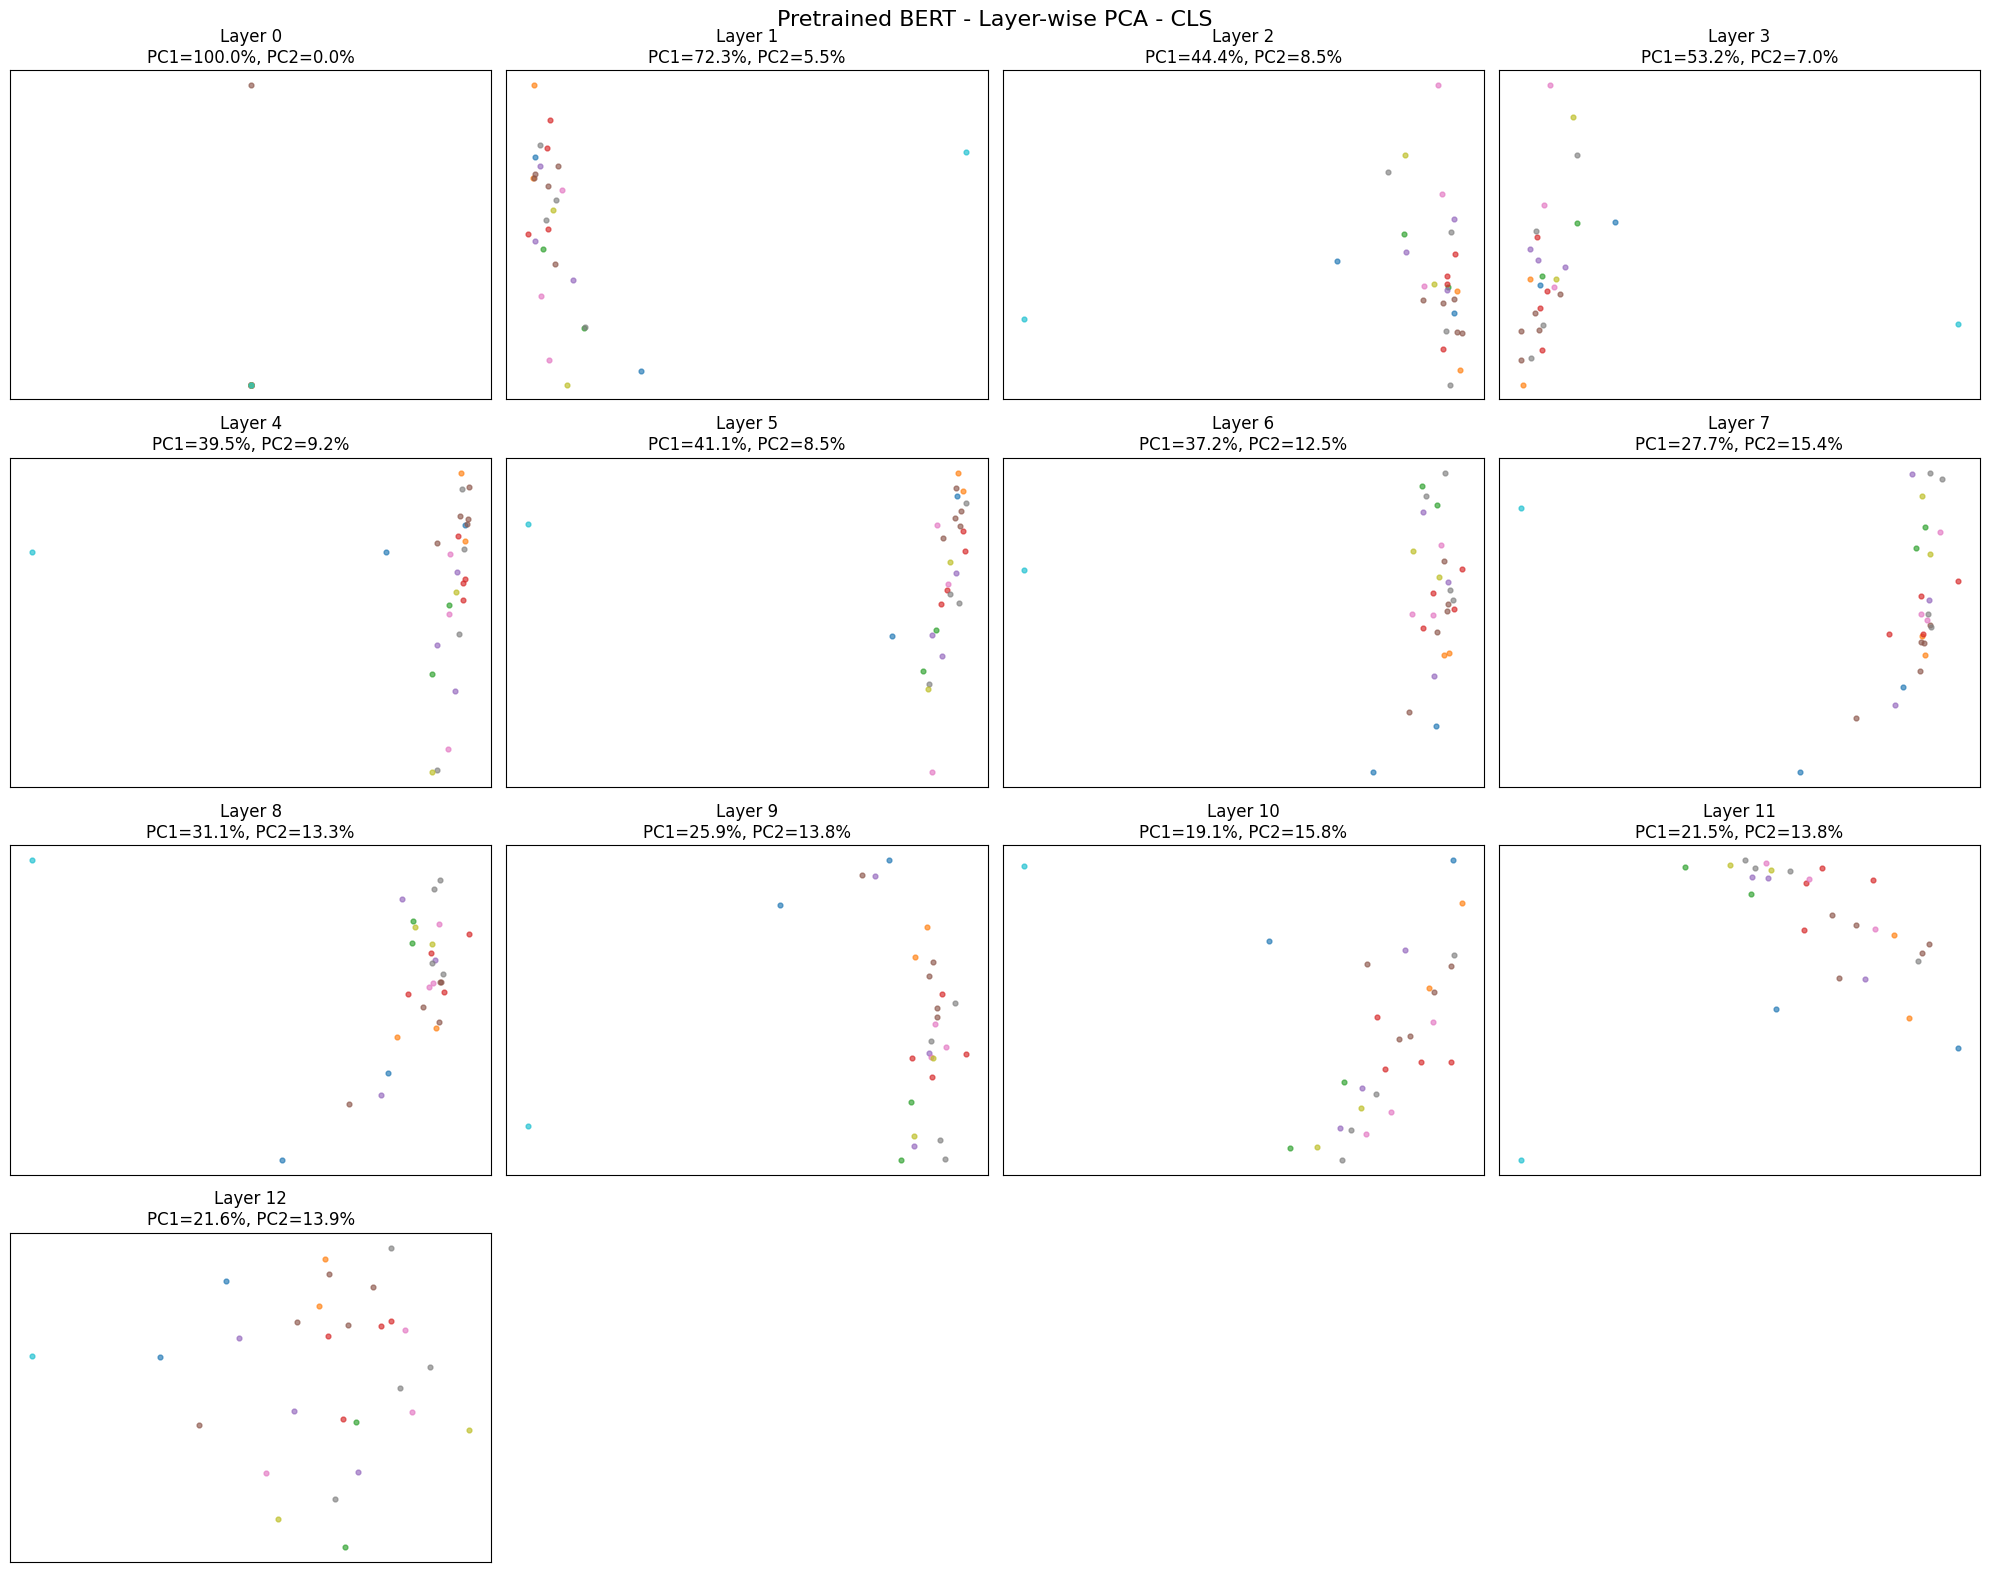

In [49]:
# =========================================
# Plot pretrained BERT layer-wise PCA grid
# =========================================

pretrained_grid_file = os.path.join(
    OUTPUT_DIR,
    f"pretrained_all_layers_{POOLING}_grid.png"
)

plot_all_layers_grid(
    layer_vectors=pretrained_layer_vectors,
    labels=y_labels,
    model_name="Pretrained BERT",
    output_file=pretrained_grid_file,
    show_plot=True
)

<h2>Plot Full Fine-Tuned BERT Grid</h2>

Saved: layerwise_bert_visualizations/finetuned_all_layers_cls_grid.png


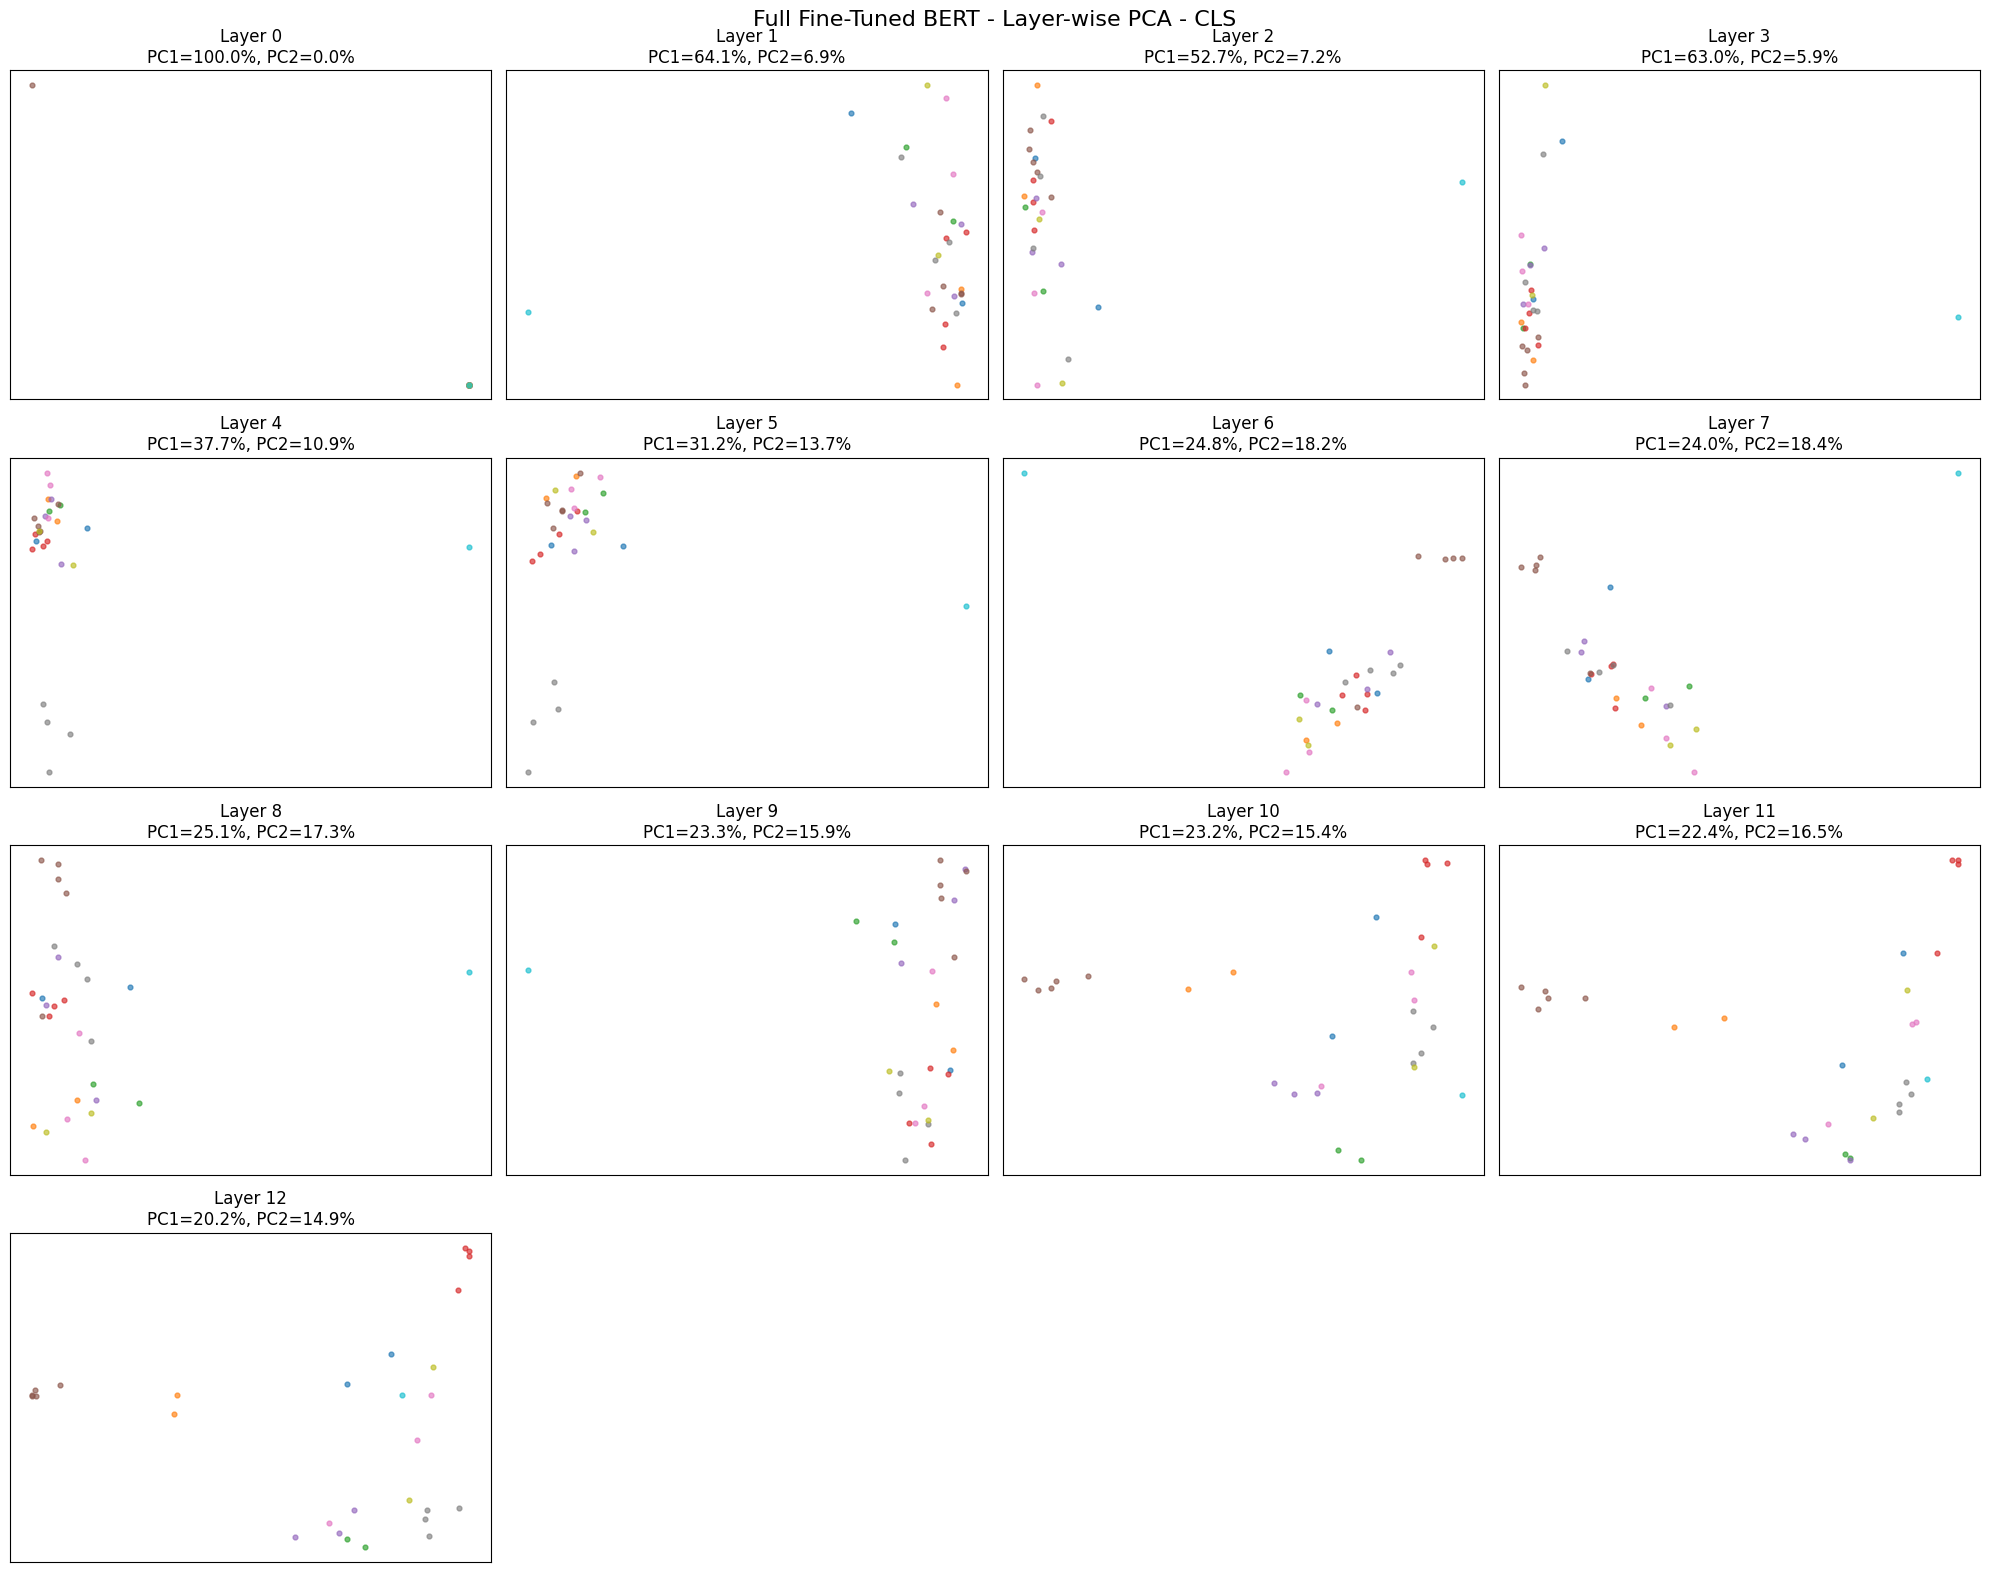

In [50]:
# =========================================
# Plot full fine-tuned BERT layer-wise PCA grid
# =========================================

finetuned_grid_file = os.path.join(
    OUTPUT_DIR,
    f"finetuned_all_layers_{POOLING}_grid.png"
)

plot_all_layers_grid(
    layer_vectors=finetuned_layer_vectors,
    labels=y_labels,
    model_name="Full Fine-Tuned BERT",
    output_file=finetuned_grid_file,
    show_plot=True
)

<h2>Compute Layer-Wise Silhouette Score</h2>

In [51]:
# =========================================
# Compute layer-wise class separability
# =========================================

def compute_layer_silhouette_scores(layer_vectors, labels):
    """
    Compute the silhouette score for each BERT layer.

    A higher silhouette score means that samples from the same class
    are closer to each other and farther from other classes.
    """
    scores = {}

    for layer_idx, vectors in layer_vectors.items():

        try:
            score = silhouette_score(
                vectors,
                labels,
                metric="euclidean"
            )

        except Exception as error:
            print(f"Layer {layer_idx} failed:", error)
            score = np.nan

        scores[layer_idx] = score

    return scores

pretrained_silhouette_scores = compute_layer_silhouette_scores(pretrained_layer_vectors, y_labels)
finetuned_silhouette_scores = compute_layer_silhouette_scores(finetuned_layer_vectors, y_labels_finetuned)


print("Pretrained BERT silhouette scores:")
print(pretrained_silhouette_scores)

print("Full fine-tuned BERT silhouette scores:")
print(finetuned_silhouette_scores)

Pretrained BERT silhouette scores:
{0: np.float32(0.0), 1: np.float32(-0.10717071), 2: np.float32(-0.04338574), 3: np.float32(-0.04071167), 4: np.float32(0.02346206), 5: np.float32(-0.0056530535), 6: np.float32(-0.05727542), 7: np.float32(-0.06839849), 8: np.float32(-0.05616344), 9: np.float32(-0.046902265), 10: np.float32(-0.036593586), 11: np.float32(-0.025188714), 12: np.float32(-0.015998544)}
Full fine-tuned BERT silhouette scores:
{0: np.float32(0.0), 1: np.float32(-0.104762845), 2: np.float32(-0.033777114), 3: np.float32(-0.023992036), 4: np.float32(0.07462341), 5: np.float32(0.094652854), 6: np.float32(0.05581556), 7: np.float32(0.049692832), 8: np.float32(0.05499816), 9: np.float32(0.098647974), 10: np.float32(0.22080752), 11: np.float32(0.2341325), 12: np.float32(0.29369855)}


<h2>Plot Layer-Wise Silhouette Scores</h2>

In [52]:
# =========================================
# Plot layer-wise silhouette scores
# This version saves the plot and also displays it inside the notebook.
# =========================================

def plot_layerwise_silhouette_scores(
    pretrained_scores,
    finetuned_scores,
    output_file=None,
    show_plot=True
):
    """
    Plot silhouette score changes across BERT layers.

    Args:
        pretrained_scores:
            Dictionary where key = layer index and value = silhouette score
            for the pretrained BERT model.

        finetuned_scores:
            Dictionary where key = layer index and value = silhouette score
            for the full fine-tuned BERT model.

        output_file:
            Optional path for saving the plot.
            If None, the figure will not be saved.

        show_plot:
            If True, display the plot inside the notebook.
    """

    # Sort layer indices to make sure the x-axis is ordered correctly
    layers = sorted(pretrained_scores.keys())

    # Extract pretrained scores in layer order
    pretrained_values = [pretrained_scores[layer_idx] for layer_idx in layers]


    # Extract fine-tuned scores in layer order
    finetuned_values = [finetuned_scores[layer_idx] for layer_idx in layers]


    # Create the figure
    plt.figure(figsize=(10, 6))

    # Plot pretrained BERT silhouette scores
    plt.plot(
        layers,
        pretrained_values,
        marker="o",
        linewidth=2,
        label="Pretrained BERT"
    )

    # Plot full fine-tuned BERT silhouette scores
    plt.plot(
        layers,
        finetuned_values,
        marker="o",
        linewidth=2,
        label="Full Fine-Tuned BERT"
    )

    # Add axis labels and title
    plt.xlabel("Layer")
    plt.ylabel("Silhouette Score")
    plt.title("Layer-wise Class Separability")

    # Add x-axis ticks for all layers
    plt.xticks(layers)

    # Add grid and legend
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Improve layout
    plt.tight_layout()

    # Save the plot if an output path is provided
    if output_file is not None:
        plt.savefig(output_file, dpi=200, bbox_inches="tight")
        print("Saved:", output_file)

    # Display the plot inside the notebook
    if show_plot:
        plt.show()
    else:
        plt.close()

Saved: layerwise_bert_visualizations/layerwise_silhouette_cls.png


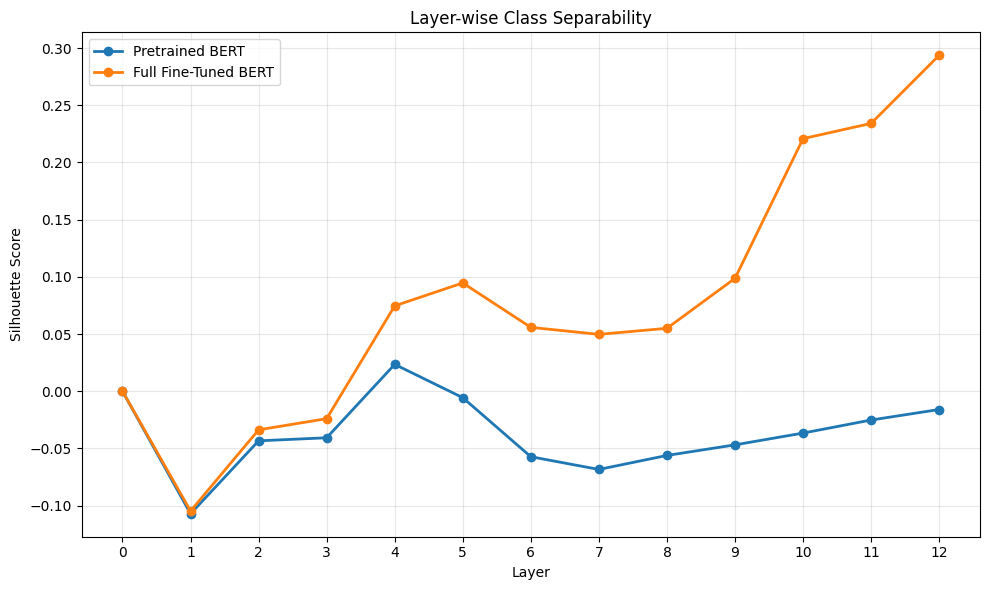

In [53]:
# =========================================
# Save and display the layer-wise silhouette plot
# =========================================

silhouette_plot_file = os.path.join(
    OUTPUT_DIR,
    f"layerwise_silhouette_{POOLING}.png"
)

plot_layerwise_silhouette_scores(
    pretrained_scores=pretrained_silhouette_scores,
    finetuned_scores=finetuned_silhouette_scores,
    output_file=silhouette_plot_file,
    show_plot=True
)